In [46]:
import sys
print(sys.executable)

C:\Users\eoinc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

print("Everything imported successfully.")

Everything imported successfully.


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

print("All good.")

All good.


# Group Project (Part 1 + Part 2): Data Quality Report and Data Quality Plan

This notebook is a clean, structured version of your Part 1 + Part 2 workflow for:
- **Part 1 (DQR):** data understanding + initial cleaning on training data only
- **Part 2 (DQP):** feature-by-feature plan + implemented cleaning decisions

Dataset used:
- `ppr-group-22312913-train.csv` only

Target feature:
- `Price (€)`

Before running this notebook make sure the run the following commands in your terminal to download the required packages:
- python3 -m venv .venv
- source .venv/bin/activate
- pip install -r requirements.txt


## Notebook Roadmap

1. Load and inspect raw training data
2. Convert feature types for analysis
3. Run core quality checks (missingness, duplicates, constants)
4. Test and validate the Eircode routing-key strategy (first 3 characters)
5. Produce DQR tables and focused visualisations
6. Write and implement the DQP (final cleaning decisions)
7. Validate final dataset (no NaN values) and export files


In [49]:
import warnings
warnings.filterwarnings('ignore')

import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

try:
    import seaborn as sns
    sns.set_style('whitegrid')
    USE_SEABORN = True
except Exception:
    USE_SEABORN = False

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)


## Step 1: Load Dataset and Basic Inspection

This step confirms the dataset dimensions, feature names, and raw types.


In [50]:
train_path = 'ppr-group-22312913-train.csv'
df_raw = pd.read_csv(train_path)

# Raw transaction signature columns (used for dedup before feature reductions)
RAW_FEATURE_COLS = [
    'Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (€)',
    'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description'
]

# Add stable row id for traceability
df_raw = df_raw.reset_index(drop=True)
df_raw['row_id'] = df_raw.index + 1

raw_dup_count = int(df_raw.duplicated(subset=RAW_FEATURE_COLS).sum())
print('Raw train shape (before raw-signature dedup):', df_raw.shape)
print('Raw duplicate rows on full transaction signature:', raw_dup_count)

# Remove exact raw-signature duplicates once
df_raw = df_raw.drop_duplicates(subset=RAW_FEATURE_COLS, keep='first').copy()
print('Raw train shape (after raw-signature dedup):', df_raw.shape)

print('\nColumns:')
print(df_raw.columns.tolist())
print('\nRaw dtypes:')
print(df_raw.dtypes)

display(df_raw.head(5))


Raw train shape (before raw-signature dedup): (54000, 10)
Raw duplicate rows on full transaction signature: 8
Raw train shape (after raw-signature dedup): (53992, 10)

Columns:
['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (€)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description', 'row_id']

Raw dtypes:
Date of Sale (dd/mm/yyyy)      str
Address                        str
County                         str
Eircode                        str
Price (€)                      str
Not Full Market Price          str
VAT Exclusive                  str
Description of Property        str
Property Size Description      str
row_id                       int64
dtype: object


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,row_id
0,01/04/2016,"7 MARLTON DEMESNE, DEMESNE, WICKLOW",Wicklow,NaN,"€450,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,1
1,15/09/2016,"90 SLIEVE RUA DR, KILMACUD, BLACKROCK",Dublin,NaN,"€560,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,2
2,21/12/2016,"APT. 1 ABOVE BERGERACS, MAIN STREET, ROASREA",Tipperary,NaN,"€44,200.00",No,No,Second-Hand Dwelling house /Apartment,NaN,3
3,17/08/2016,"6 MARIEMOUNT GROVE, BALLINAMORE, COUNTY LEITRIM",Leitrim,NaN,"€65,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,4
4,19/04/2016,"THE GLADE, TYMULLEN, MONASTERBOICE",Louth,NaN,"€400,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,5


* A quick note, we can add row_id for tracability if needs to be later in modeling, for the moment there isn't much need for it.

## Step 2: Reusable Data-Quality Helpers

These helper functions are used repeatedly for DQR summaries and checks.


In [51]:
def quality_overview(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing_count': df.isna().sum(),
        'missing_%': (df.isna().mean() * 100).round(2),
        'nunique_including_nan': df.nunique(dropna=False),
    })
    return out.sort_values(['missing_%', 'nunique_including_nan'], ascending=[False, False])


def numeric_summary(df: pd.DataFrame) -> pd.DataFrame:
    cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if not cols:
        return pd.DataFrame()
    return df[cols].describe().T


def categorical_summary(df: pd.DataFrame) -> pd.DataFrame:
    cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    if not cols:
        return pd.DataFrame()
    return df[cols].describe().T


## Step 3: Type Conversion for DQR Analysis

Decisions in this stage:
- Parse `Date of Sale (dd/mm/yyyy)` into datetime
- Parse `Price (€)` into numeric euro values
- Cast low-cardinality fields to `category`
- Keep `Address` as free text (high cardinality)


In [52]:
df_dqr = df_raw.copy()

# Parse date
DATE_COL = 'Date of Sale (dd/mm/yyyy)'
df_dqr[DATE_COL] = pd.to_datetime(df_dqr[DATE_COL], format='%d/%m/%Y', errors='coerce')

# Parse price
PRICE_COL = 'Price (€)'
df_dqr[PRICE_COL] = (
    df_dqr[PRICE_COL]
    .astype('string')
    .str.replace('€', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df_dqr[PRICE_COL] = pd.to_numeric(df_dqr[PRICE_COL], errors='coerce')

# Cast categories
category_cols = [
    'County',
    'Eircode',
    'Not Full Market Price',
    'VAT Exclusive',
    'Description of Property',
    'Property Size Description',
]
for col in category_cols:
    df_dqr[col] = df_dqr[col].astype('category')

# Address kept as text
df_dqr['Address'] = df_dqr['Address'].astype('string').str.strip()

print('Converted dtypes:')
print(df_dqr.dtypes)


Converted dtypes:
Date of Sale (dd/mm/yyyy)    datetime64[us]
Address                              string
County                             category
Eircode                            category
Price (€)                           Float64
Not Full Market Price              category
VAT Exclusive                      category
Description of Property            category
Property Size Description          category
row_id                                int64
dtype: object


## Step 4: Core Quality Checks (Raw + Converted)

This captures the basic quality profile expected in Part 1.


In [53]:
print('Duplicate rows (raw transaction signature):', int(df_dqr.duplicated(subset=RAW_FEATURE_COLS).sum()))
print('Duplicate columns:', int(df_dqr.T.duplicated().sum()))

constant_cols = [c for c in df_dqr.columns if df_dqr[c].nunique(dropna=False) <= 1]
print('Constant columns:', constant_cols)

print('\nQuality overview:')
display(quality_overview(df_dqr))

print('\nPrice quick checks:')
print('Missing prices:', int(df_dqr[PRICE_COL].isna().sum()))
print('Min price:', float(df_dqr[PRICE_COL].min()))
print('Max price:', float(df_dqr[PRICE_COL].max()))

print('\nDate quick checks:')
print('Missing dates:', int(df_dqr[DATE_COL].isna().sum()))
print('Min date:', df_dqr[DATE_COL].min())
print('Max date:', df_dqr[DATE_COL].max())


Duplicate rows (raw transaction signature): 0
Duplicate columns: 0
Constant columns: []

Quality overview:


,dtype,missing_count,missing_%,nunique_including_nan
Property Size Description,category,51217,94.86,5
Eircode,category,37091,68.70,16850
row_id,int64,0,0.00,53992
Address,string,0,0.00,53315
Price (€),Float64,0,0.00,6689
Date of Sale (dd/mm/yyyy),datetime64[us],0,0.00,2479
County,category,0,0.00,26
Description of Property,category,0,0.00,3
Not Full Market Price,category,0,0.00,2
VAT Exclusive,category,0,0.00,2



Price quick checks:
Missing prices: 0
Min price: 5586.84
Max price: 111280172.0

Date quick checks:
Missing dates: 0
Min date: 2016-01-01 00:00:00
Max date: 2024-12-31 00:00:00


## Step 5.1: Eircode Strategy - Routing Key (First 3 Characters)

Your method is preserved and formalised:
1. Convert full Eircode to routing key (first 3 chars)
2. Infer routing key from `Address + County` using a routing reference table
3. Validate inference error on rows where true routing key is known
4. Fill missing routing keys only where inference exists

This gives a reproducible and explainable alternative to external APIs.


In [54]:
# Time helpers for trend analysis

df_dqr['Year'] = df_dqr[DATE_COL].dt.year
df_dqr['Month'] = df_dqr[DATE_COL].dt.month

# Original routing key (from existing Eircode)
df_dqr['Eircode_Routing'] = df_dqr['Eircode'].astype('string').str[:3].str.upper()

missing_eircode_full = df_dqr['Eircode'].isna().mean() * 100
missing_routing = df_dqr['Eircode_Routing'].isna().mean() * 100

print(f'Missing full Eircode before inference: {missing_eircode_full:.2f}%')
print(f'Missing routing key before inference: {missing_routing:.2f}%')

print('\nEircode missing % by year (full code):')
year_missing = df_dqr.groupby('Year')['Eircode'].apply(lambda s: s.isna().mean() * 100)
display(year_missing.round(2))


Missing full Eircode before inference: 68.70%
Missing routing key before inference: 68.70%

Eircode missing % by year (full code):


Year
2016   99.70
2017   99.77
2018   99.75
2019   99.75
2020   99.40
2021   48.35
2022   23.33
2023   23.74
2024   24.50
Name: Eircode, dtype: float64

In [55]:
routing_text = """
A92,Ardee,Louth
Y14,Arklow,Wicklow
A84,Ashbourne,Meath
H65,Athenry,Galway
N37,Athlone,Westmeath
R14,Athy,Kildare
K32,Balbriggan,Dublin
F26,Ballina,Mayo
H53,Ballinasloe,Galway
P31,Ballincollig,Cork
F31,Ballinrobe,Mayo
A75,Ballybay,Monaghan
A41,Ballyboughal,Dublin
F35,Ballyhaunis,Mayo
F56,Ballymote,Sligo
P72,Bandon,Cork
P75,Bantry,Cork
H14,Belturbet,Cavan
R42,Birr,Offaly
A94,Blackrock,Dublin
F52,Boyle,Roscommon
A98,Bray,Wicklow
V23,Caherciveen,Kerry
E21,Cahir,Tipperary
R93,Carlow,Carlow
A81,Carrickmacross,Monaghan
N41,Carrick-on-Shannon,Leitrim
E32,Carrick-on-Suir,Tipperary
P43,Carrigaline,Cork
E25,Cashel,Tipperary
F23,Castlebar,Mayo
A75,Castleblaney,Monaghan
F45,Castlerea,Roscommon
H12,Cavan,Cavan
P56,Charleville,Cork
F12,Claremorris,Mayo
H71,Clifden,Galway
P85,Clonakilty,Cork
H23,Clones,Monaghan
E91,Clonmel,Tipperary
P24,Cobh,Cork
H16,Cootehill,Cavan
T12,Cork (centre and southside),Cork
T23,Cork (northside),Cork
P14,Crookstown,Cork
P32,Donoughmore,Cork
P47,Dunmanway,Cork
T56,Watergrasshill,Cork
T34,Whitechurch,Cork
R56,Curragh Camp,Kildare
A63,Delgany,Wicklow
F94,Donegal,Donegal
A92,Drogheda,Louth
D01,Dublin 1,Dublin
D02,Dublin 2,Dublin
D03,Dublin 3,Dublin
D04,Dublin 4,Dublin
D05,Dublin 5,Dublin
D06,Dublin 6,Dublin
D6W,Dublin 6W,Dublin
D07,Dublin 7,Dublin
D08,Dublin 8,Dublin
D09,Dublin 9,Dublin
D10,Dublin 10,Dublin
D11,Dublin 11,Dublin
D12,Dublin 12,Dublin
D13,Dublin 13,Dublin
D14,Dublin 14,Dublin
D15,Dublin 15,Dublin
D16,Dublin 16,Dublin
D17,Dublin 17,Dublin
D18,Dublin 18,Dublin
D20,Dublin 20,Dublin
D22,Dublin 22,Dublin
D24,Dublin 24,Dublin
A86,Dunboyne,Meath
A91,Dundalk,Louth
X35,Dungarvan,Waterford
A85,Dunshaughlin,Meath
R45,Edenderry,Offaly
A83,Enfield,Meath
V95,Ennis,Clare
Y21,Enniscorthy,Wexford
P61,Fermoy,Cork
H91,Galway,Galway
A42,Garristown,Dublin
A96,Glenageary,Dublin
Y25,Gorey,Wexford
A63,Greystones,Wicklow
A82,Kells,Meath
A63,Kilcoole,Wicklow
R51,Kildare,Kildare
R95,Kilkenny,Kilkenny
V93,Killarney,Kerry
X42,Kilmacthomas,Waterford
V35,Kilmallock,Limerick
V15,Kilrush,Clare
A82,Kingscourt,Cavan
P17,Kinsale,Cork
A92,Laytown-Bettystown-Mornington,Meath
F92,Letterkenny,Donegal
F93,Lifford,Donegal
V94,Limerick,Limerick
V31,Listowel,Kerry
T45,Little Island,Cork
N39,Longford,Longford
H62,Loughrea,Galway
K78,Lucan,Dublin
K45,Lusk,Dublin
P12,Macroom,Cork
K36,Malahide,Dublin
P51,Mallow,Cork
W23,Maynooth,Kildare
P25,Midleton,Cork
P67,Mitchelstown,Cork
H18,Monaghan,Monaghan
W34,Monasterevin,Kildare
A94,Monkstown,Dublin
R21,Muine Bheag,Carlow
N91,Mullingar,Westmeath
W91,Naas,Kildare
C15,Navan,Meath
E45,Nenagh,Tipperary
Y34,New Ross,Wexford
W12,Newbridge,Kildare
A63,Newcastle,Wicklow
V42,Newcastle West,Limerick
A63,Newtownmountkennedy,Wicklow
A45,Portlaoise,Laois
A67,Rathnew,Wicklow
A85,Ratoath,Meath
F42,Roscommon,Roscommon
E53,Roscrea,Tipperary
K56,Rush,Dublin
V14,Shannon,Clare
K34,Skerries,Dublin
P81,Skibbereen,Cork
F91,Sligo,Sligo
A83,Summerhill,Meath
K67,Swords,Dublin
E41,Thurles,Tipperary
E34,Tipperary,Tipperary
V92,Tralee,Kerry
H54,Tuam,Galway
R35,Tullamore,Offaly
A82,Virginia,Cavan
X91,Waterford,Waterford
F28,Westport,Mayo
Y35,Wexford,Wexford
A67,Wicklow,Wicklow
P36,Youghal,Cork
"""

routing_df = pd.read_csv(
    io.StringIO(routing_text),
    sep=',',
    header=None,
    names=['Eircode3', 'Town', 'County'],
)

routing_df = routing_df[routing_df['Town'] != routing_df['County']].copy()
routing_df['Town_up'] = (
    routing_df['Town']
    .astype('string')
    .str.upper()
    .str.replace(r'[^A-Z0-9]+', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

print('Routing reference rows:', len(routing_df))


Routing reference rows: 136


In [56]:
# Clean address for matching

df_dqr['Address_clean'] = (
    df_dqr['Address']
    .astype('string')
    .str.upper()
    .str.replace(r'[^A-Z0-9]+', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Inferred routing key candidate (from address + county)
df_dqr['Eircode_Routing_Inferred'] = pd.NA

town_to_code = routing_df.set_index('Town_up')['Eircode3'].to_dict()
town_to_county = routing_df.set_index('Town_up')['County'].to_dict()

for town, code in town_to_code.items():
    cnty = town_to_county[town]
    town_re = rf'\b{re.escape(town)}\b'
    hit = df_dqr['Address_clean'].str.contains(town_re, na=False)
    county_match = df_dqr['County'].astype('string') == cnty
    empty_target = df_dqr['Eircode_Routing_Inferred'].isna()
    df_dqr.loc[empty_target & hit & county_match, 'Eircode_Routing_Inferred'] = code

print('Rows with inferred routing key:', int(df_dqr['Eircode_Routing_Inferred'].notna().sum()))


Rows with inferred routing key: 25764


In [57]:
# Validation: compare inferred routing key with true routing key where both are available

m = df_dqr['Eircode_Routing_Inferred'].notna() & df_dqr['Eircode_Routing'].notna()
compared_rows = int(m.sum())
errors = int((df_dqr.loc[m, 'Eircode_Routing_Inferred'] != df_dqr.loc[m, 'Eircode_Routing']).sum())
error_rate = (errors / compared_rows * 100) if compared_rows else np.nan

print('Compared rows:', compared_rows)
print('Match rows:', compared_rows - errors)
print('Mismatch rows:', errors)
print(f'Error rate: {error_rate:.2f}%')

mismatch_df = df_dqr.loc[m & (df_dqr['Eircode_Routing_Inferred'] != df_dqr['Eircode_Routing'])].copy()

print('\nTop mismatch counties:')
display(mismatch_df['County'].value_counts().head(10))

print('\nMismatches by year:')
display(mismatch_df['Year'].value_counts().sort_index())


Compared rows: 8773
Match rows: 8401
Mismatch rows: 372
Error rate: 4.24%

Top mismatch counties:


County
Dublin       142
Laois        140
Cork          17
Galway        12
Tipperary     11
Mayo           8
Kildare        6
Offaly         6
Clare          4
Donegal        4
Name: count, dtype: int64


Mismatches by year:


Year
2016      2
2020      1
2021     65
2022     94
2023     97
2024    113
Name: count, dtype: int64

In [58]:
# Apply inference only where routing key is missing

missing_before = df_dqr['Eircode_Routing'].isna().mean() * 100
fill_mask = df_dqr['Eircode_Routing'].isna() & df_dqr['Eircode_Routing_Inferred'].notna()
df_dqr.loc[fill_mask, 'Eircode_Routing'] = df_dqr.loc[fill_mask, 'Eircode_Routing_Inferred']
missing_after = df_dqr['Eircode_Routing'].isna().mean() * 100

print(f'Routing-key missing before fill: {missing_before:.2f}%')
print(f'Routing-key missing after fill : {missing_after:.2f}%')

Routing-key missing before fill: 68.70%
Routing-key missing after fill : 37.23%


## Step 5.2: Description of Property.

Method is preserved and formalised:
1. First check the different count of unique objects.
2. Figure out that Teach/Arasan Conaithe Athaimhe in Irish means Refurbished (2nd hand).
3. With only 2 values it makes sense to convert it to just second hand dwelling.
4. Make it a Boolean column yes or no for second hand.

This gives a reproducible.

In [59]:
df_dqr['Description of Property'].value_counts(dropna=False)

Description of Property
Second-Hand Dwelling house /Apartment    44402
New Dwelling house /Apartment             9588
Teach/Árasán Cónaithe Atháimhe               2
Name: count, dtype: int64

In [60]:
df_dqr["Description of Property"] = df_dqr["Description of Property"].replace(
    "Teach/Árasán Cónaithe Atháimhe",
    "Second-Hand Dwelling house /Apartment"
)

df_dqr['Description of Property'].value_counts(dropna=False)

Description of Property
Second-Hand Dwelling house /Apartment    44404
New Dwelling house /Apartment             9588
Teach/Árasán Cónaithe Atháimhe               0
Name: count, dtype: int64

In [61]:
df_dqr['Is_Second_Hand'] = df_dqr['Description of Property'].str.lower().eq('second-hand dwelling house /apartment')
df_dqr['Is_Second_Hand'] = df_dqr['Is_Second_Hand'].map({True: 'Yes', False: 'No'})

display(df_dqr['Is_Second_Hand'].value_counts(dropna=False))
display(df_dqr[['Description of Property','Is_Second_Hand']].head(10))

Is_Second_Hand
Yes    44404
No      9588
Name: count, dtype: int64

,Description of Property,Is_Second_Hand
0,Second-Hand Dwelling house /Apartment,Yes
1,Second-Hand Dwelling house /Apartment,Yes
2,Second-Hand Dwelling house /Apartment,Yes
3,Second-Hand Dwelling house /Apartment,Yes
4,Second-Hand Dwelling house /Apartment,Yes
5,Second-Hand Dwelling house /Apartment,Yes
6,Second-Hand Dwelling house /Apartment,Yes
7,New Dwelling house /Apartment,No
8,Second-Hand Dwelling house /Apartment,Yes
9,Second-Hand Dwelling house /Apartment,Yes


## Step 6: Remove Duplicates and Save Part 1 Cleaned Dataset

Workflow here follows a strict order for reproducibility:
1. Raw-signature duplicates removed first.
2. Address normalized and conservatively standardized (`STREET->ST`, `ROAD->RD`, `AVENUE->AVE`).
3. Use explicit `dup_key` (excluding `row_id`) and check for:
   - true duplicates on full-date cleaned transaction fields
   - groups where all fields match except address (potential inconsistencies)
4. Keep `row_id` in canonical export for traceability.


In [62]:
print(df_dqr.columns.tolist())

['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (€)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description', 'row_id', 'Year', 'Month', 'Eircode_Routing', 'Address_clean', 'Eircode_Routing_Inferred', 'Is_Second_Hand']


In [63]:
s = df_dqr['Address_clean'].copy()

# quick token profile
token_counts = s.str.split().explode().value_counts()
display(token_counts.head(30))

pairs = {
    "ROAD":"RD",
    "STREET":"ST",
    "AVENUE":"AVE",
    "DRIVE":"DR",
    "COURT":"CT",
    "PLACE":"PL",
    "SQUARE":"SQ",
    "TERRACE":"TER",
    "CRESCENT":"CRES",
    "LANE":"LN",
    "APARTMENT":"APT"
}

rows = []
for full, abbr in pairs.items():
    full_n = s.str.contains(rf"\b{full}\b", na=False).sum()
    abbr_n = s.str.contains(rf"\b{abbr}\b", na=False).sum()
    s2 = s.str.replace(rf"\b{full}\b", abbr, regex=True)
    uniq_drop = s.nunique() - s2.nunique()
    rows.append([full, abbr, int(full_n), int(abbr_n), int(uniq_drop)])

impact = pd.DataFrame(rows, columns=["full","abbr","full_count","abbr_count","unique_drop"])
display(impact.sort_values("unique_drop", ascending=False))


Address_clean
DUBLIN      11905
RD           6940
THE          5794
CO           4459
ROAD         4365
PARK         4024
ST           3946
CORK         2905
COURT        2673
1            2234
APT          2114
4            1975
3            1942
2            1904
15           1822
7            1725
8            1723
AVE          1703
6            1701
5            1661
GALWAY       1660
9            1625
12           1528
11           1438
LIMERICK     1385
HOUSE        1356
KILDARE      1304
14           1282
AVENUE       1217
VIEW         1205
Name: count, dtype: int64

,full,abbr,full_count,abbr_count,unique_drop
1,STREET,ST,996,3758,9
0,ROAD,RD,4316,6883,4
2,AVENUE,AVE,1212,1699,1
3,DRIVE,DR,698,916,0
4,COURT,CT,2665,30,0
5,PLACE,PL,768,14,0
6,SQUARE,SQ,417,576,0
7,TERRACE,TER,687,0,0
8,CRESCENT,CRES,773,0,0
9,LANE,LN,1010,0,0


In [64]:
# Build Area Code from routing key (prefer explicit routing, fallback to inferred), keep first 3 chars
area_from_routing = df_dqr['Eircode_Routing'].astype('string').str[:3].str.upper()
area_from_inferred = df_dqr['Eircode_Routing_Inferred'].astype('string').str[:3].str.upper()

df_dqr['Area Code'] = area_from_routing
missing_mask = df_dqr['Area Code'].isna()
df_dqr.loc[missing_mask, 'Area Code'] = area_from_inferred[missing_mask]

# Final normalisation and cast
df_dqr['Area Code'] = df_dqr['Area Code'].fillna('Unknown').astype('category')

# Conservative address standardisation for common suffix variants
# Keep a pre-standardization copy for diagnostics only.
df_dqr['Address_clean_base'] = df_dqr['Address_clean'].astype('string')
for full, abbr in {'STREET': 'ST', 'ROAD': 'RD', 'AVENUE': 'AVE'}.items():
    df_dqr['Address_clean'] = df_dqr['Address_clean'].str.replace(rf'\b{full}\b', abbr, regex=True)

addr_unique_before = int(df_dqr['Address_clean_base'].nunique(dropna=False))
addr_unique_after = int(df_dqr['Address_clean'].nunique(dropna=False))
print('Address unique count before std:', addr_unique_before)
print('Address unique count after std :', addr_unique_after)
print('Address unique drop from std   :', addr_unique_before - addr_unique_after)

# Explicit duplicate keys for cleaned-transaction dedup logic (row_id intentionally excluded)
dup_key_base = [
    DATE_COL, 'Address_clean_base', 'County', 'Area Code', PRICE_COL,
    'Not Full Market Price', 'VAT Exclusive', 'Is_Second_Hand'
]
dup_key_std = [
    DATE_COL, 'Address_clean', 'County', 'Area Code', PRICE_COL,
    'Not Full Market Price', 'VAT Exclusive', 'Is_Second_Hand'
]
dup_key = dup_key_std

dup_base_count = int(df_dqr.duplicated(subset=dup_key_base).sum())
dup_std_count = int(df_dqr.duplicated(subset=dup_key_std).sum())
print('Duplicates on full-date key before address std:', dup_base_count)
print('Duplicates on full-date key after address std :', dup_std_count)
print('Extra duplicates introduced by address std    :', dup_std_count - dup_base_count)

# Diagnostic: same transaction fields except address, but multiple address values
key_without_address = [c for c in dup_key if c != 'Address_clean']
ambiguous_groups = (
    df_dqr
    .groupby(key_without_address, dropna=False)
    .agg(rows=('row_id', 'size'), unique_addr=('Address_clean', 'nunique'))
    .reset_index()
)
ambiguous_groups = ambiguous_groups[(ambiguous_groups['rows'] > 1) & (ambiguous_groups['unique_addr'] > 1)]
print('Potential same-transaction groups with different addresses:', len(ambiguous_groups))

if len(ambiguous_groups) > 0:
    sample_keys = ambiguous_groups.head(5)[key_without_address]
    sample_rows = sample_keys.merge(
        df_dqr[key_without_address + ['row_id', 'Address_clean_base', 'Address_clean']],
        on=key_without_address,
        how='left'
    ).sort_values(key_without_address + ['row_id'])
    print('Sample ambiguous groups (first 5 keys):')
    display(sample_rows)

# Check duplicates on cleaned full-date transaction key and dedup only on this key
dup_key_count_before_export = dup_std_count
print('Duplicate rows on cleaned full-date dup_key:', dup_key_count_before_export)

if dup_key_count_before_export > 0:
    dup_preview = (
        df_dqr[df_dqr.duplicated(subset=dup_key, keep=False)]
        [['row_id'] + dup_key]
        .sort_values(dup_key + ['row_id'])
        .head(20)
    )
    print('Sample duplicates on dup_key (first 20 rows):')
    display(dup_preview)

    df_dqr_nodup = df_dqr.drop_duplicates(subset=dup_key, keep='first').copy()
    print('Dropped duplicates on dup_key:', dup_key_count_before_export)
else:
    df_dqr_nodup = df_dqr.copy()
    print('No cleaned full-date duplicates dropped.')

# Simple format check for area code
invalid_area_mask = ~df_dqr_nodup['Area Code'].astype('string').str.match(r'^(Unknown|[A-Z0-9]{3})$', na=False)
print('Invalid Area Code format rows:', int(invalid_area_mask.sum()))

# Build monthly feature after dedup decision
df_dqr_nodup['Year-Month of Sale (yyyy-mm)'] = df_dqr_nodup[DATE_COL].dt.strftime('%Y-%m')

# Canonical cleaned schema for downstream parts (with row_id for traceability)
base_cols = [
    'row_id',
    'Year-Month of Sale (yyyy-mm)',
    'Address_clean',
    'County',
    'Area Code',
    'Price (€)',
    'Not Full Market Price',
    'VAT Exclusive',
    'Is_Second_Hand',
]
analysis_cols = [c for c in base_cols if c != 'row_id']

df_part1_export = df_dqr_nodup[base_cols].copy()

print('Columns after:', df_part1_export.columns.tolist())

part1_path = 'ppr-group-22312913-train-cleaned.csv'
df_part1_export.to_csv(part1_path, index=False)
print('Saved:', part1_path)


Address unique count before std: 53266
Address unique count after std : 53252
Address unique drop from std   : 14
Duplicates on full-date key before address std: 0
Duplicates on full-date key after address std : 0
Extra duplicates introduced by address std    : 0
Potential same-transaction groups with different addresses: 569
Sample ambiguous groups (first 5 keys):


,Date of Sale (dd/mm/yyyy),County,Area Code,Price (€),Not Full Market Price,VAT Exclusive,Is_Second_Hand,row_id,Address_clean_base,Address_clean
0,2016-01-26,Cork,Unknown,"232,500.00",Yes,Yes,No,4783,14 BRAMBLE HILL CASTLETREASURE DOUGLAS,14 BRAMBLE HILL CASTLETREASURE DOUGLAS
1,2016-01-26,Cork,Unknown,"232,500.00",Yes,Yes,No,5212,18 THE BRAMBLES CASTLETREASURE DOUGLAS,18 THE BRAMBLES CASTLETREASURE DOUGLAS
2,2016-01-26,Cork,Unknown,"232,500.00",Yes,Yes,No,5659,20 BRAMBLE HILL CASTLETREASURE DOUGLAS,20 BRAMBLE HILL CASTLETREASURE DOUGLAS
3,2016-02-04,Cork,Unknown,"34,723.86",No,No,Yes,2182,17 ALLOW HILL FREEMOUNT CO CORK,17 ALLOW HILL FREEMOUNT CO CORK
4,2016-02-04,Cork,Unknown,"34,723.86",No,No,Yes,2439,6 ALLOW HILL FREEMOUNT CO CORK,6 ALLOW HILL FREEMOUNT CO CORK
5,2016-02-05,Dublin,D01,"23,572.00",No,No,Yes,1666,APT 9 2 GARDINER PL DUBLIN 1,APT 9 2 GARDINER PL DUBLIN 1
6,2016-02-05,Dublin,D01,"23,572.00",No,No,Yes,2785,APT 11 2 GARDINER PLACE DUBLIN 1,APT 11 2 GARDINER PLACE DUBLIN 1
7,2016-02-05,Dublin,D01,"23,572.00",No,No,Yes,3054,APT 12 2 GARDINER PLACE DUBLIN 1,APT 12 2 GARDINER PLACE DUBLIN 1
8,2016-02-05,Dublin,D01,"23,572.00",No,No,Yes,4567,APT 8 2 GARDINER PL DUBLIN 1,APT 8 2 GARDINER PL DUBLIN 1
9,2016-02-05,Dublin,Unknown,"246,330.59",Yes,Yes,No,290,27 ROSSAN COURT WATERVILLE BLANCHARDSTOWN,27 ROSSAN COURT WATERVILLE BLANCHARDSTOWN


Duplicate rows on cleaned full-date dup_key: 0
No cleaned full-date duplicates dropped.
Invalid Area Code format rows: 0
Columns after: ['row_id', 'Year-Month of Sale (yyyy-mm)', 'Address_clean', 'County', 'Area Code', 'Price (€)', 'Not Full Market Price', 'VAT Exclusive', 'Is_Second_Hand']
Saved: ppr-group-22312913-train-cleaned.csv


* Here we see that higher standardisation of address won't give us more info, but increases the risks of data fabrication. So it is wise to stop it and use other features.
* Higher standardization risk = potential false merges/fabricated matches,
* repeat groups are relatively small (~hundreds), so limited payoff,
* safer to rely on stronger features (County, Area Code, Year-Month, property type, VAT/full-market flags).

## Step 7: DQR Tables

These tables support the written DQR with feature-level evidence.


In [65]:
print('Overview table:')
display(quality_overview(df_dqr_nodup[analysis_cols]))

print('Numeric summary:')
display(numeric_summary(df_dqr_nodup[analysis_cols]))

print('Categorical summary:')
display(categorical_summary(df_dqr_nodup[analysis_cols]))


Overview table:


,dtype,missing_count,missing_%,nunique_including_nan
Address_clean,string,0,0.00,53252
Price (€),Float64,0,0.00,6689
Area Code,category,0,0.00,154
Year-Month of Sale (yyyy-mm),str,0,0.00,108
County,category,0,0.00,26
Not Full Market Price,category,0,0.00,2
VAT Exclusive,category,0,0.00,2
Is_Second_Hand,str,0,0.00,2


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
Price (€),"53,992.00","323,710.69","950,626.38","5,586.84","159,000.00","250,000.00","362,500.00","111,280,172.00"


Categorical summary:


,count,unique,top,freq
Year-Month of Sale (yyyy-mm),53992,108,2020-12,896
Address_clean,53992,53252,TURLOUGH RD CASTLEBAR MAYO,4
County,53992,26,Dublin,16347
Area Code,53992,154,Unknown,20100
Not Full Market Price,53992,2,No,51182
VAT Exclusive,53992,2,No,44537
Is_Second_Hand,53992,2,Yes,44404


## Step 8: Focused DQR Visualisations

Visual choices here avoid noisy/low-value plots:
- **Numeric**: focus on boxplots and time trend for `Price (€)`
- **Categorical**: focus on `County`, `Area Code`, `VAT Exclusive`, `Not Full Market Price`, `Is_Second_Hand`

Skipped from general categorical plotting (by design):
- `Address` (too high cardinality)
- `Area Code` (high cardinality + missingness handling strategy)
- `Property Size Description` (very high missingness)


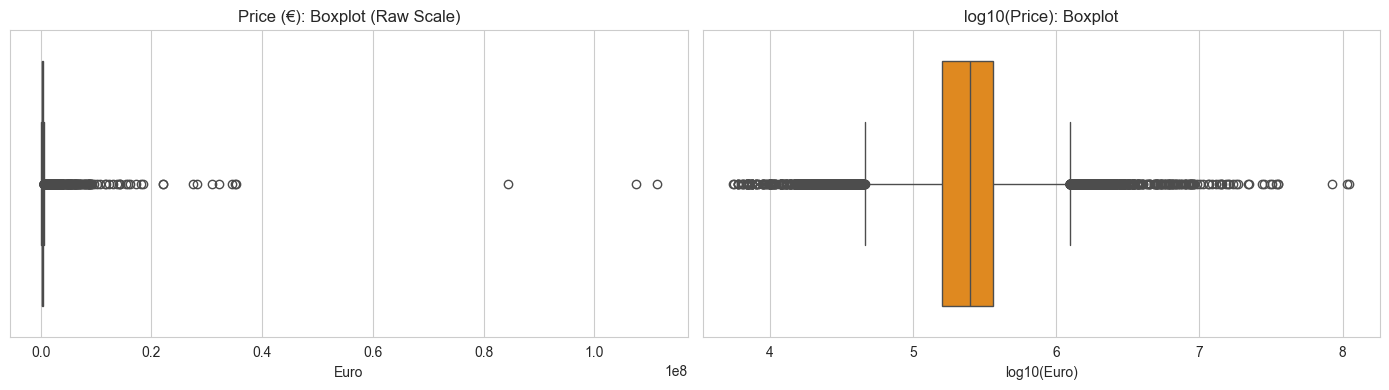

In [66]:
# Numeric visuals (boxplots + distribution diagnostics)

df_plot = df_dqr_nodup.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Price boxplot
if USE_SEABORN:
    sns.boxplot(x=df_plot[PRICE_COL], ax=axes[0], color='steelblue')
else:
    axes[0].boxplot(df_plot[PRICE_COL].dropna(), vert=False)
axes[0].set_title('Price (€): Boxplot (Raw Scale)')
axes[0].set_xlabel('Euro')

# Log-price boxplot (better for outlier-heavy distributions)
log_price = np.log10(df_plot[PRICE_COL].clip(lower=1))
if USE_SEABORN:
    sns.boxplot(x=log_price, ax=axes[1], color='darkorange')
else:
    axes[1].boxplot(log_price.dropna(), vert=False)
axes[1].set_title('log10(Price): Boxplot')
axes[1].set_xlabel('log10(Euro)')

plt.tight_layout()
plt.show()


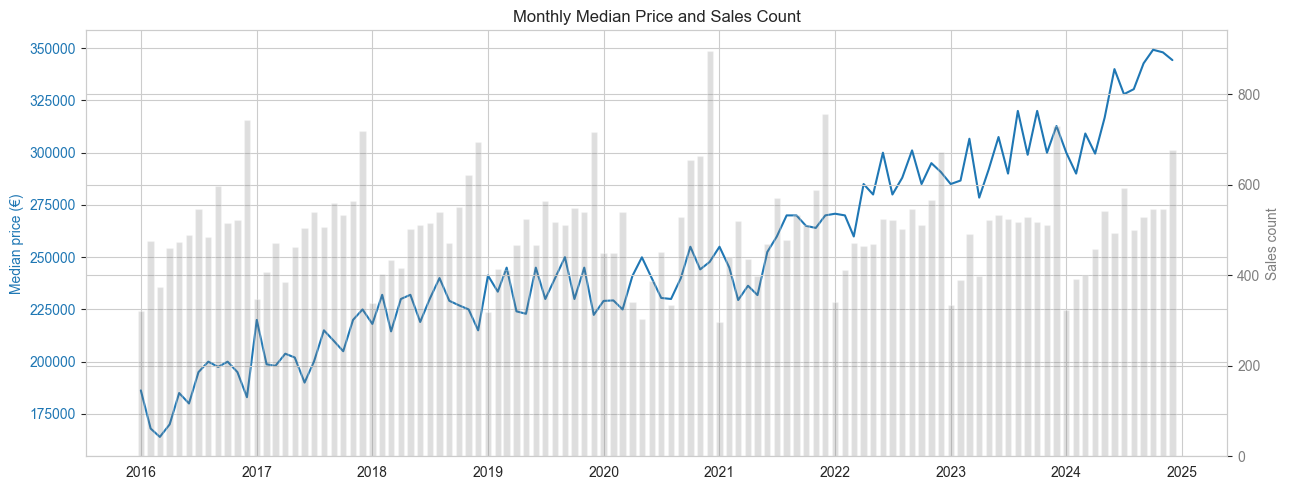

In [67]:
# Monthly trend: median price + sales volume

monthly = (
    df_plot
    .set_index(DATE_COL)
    .resample('MS')
    .agg(median_price=(PRICE_COL, 'median'), sales_count=(PRICE_COL, 'size'))
)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(monthly.index, monthly['median_price'], color='tab:blue', label='Median price')
ax1.set_ylabel('Median price (€)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_title('Monthly Median Price and Sales Count')

ax2 = ax1.twinx()
ax2.bar(monthly.index, monthly['sales_count'], alpha=0.25, color='tab:gray', width=20, label='Sales count')
ax2.set_ylabel('Sales count', color='tab:gray')
ax2.tick_params(axis='y', labelcolor='tab:gray')

fig.tight_layout()
plt.show()


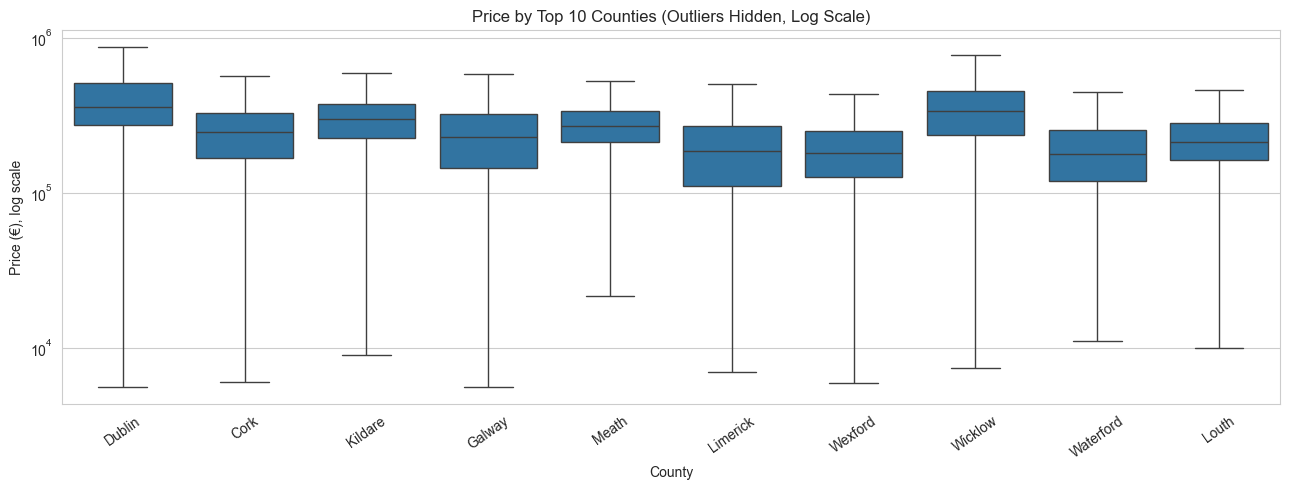

In [68]:
# Price distribution by top counties (log y for readability)

top_counties = df_plot['County'].value_counts().head(10).index.tolist()
county_price = df_plot[df_plot['County'].isin(top_counties)].copy()

plt.figure(figsize=(13, 5))
if USE_SEABORN:
    sns.boxplot(data=county_price, x='County', y=PRICE_COL, order=top_counties, showfliers=False)
else:
    county_price.boxplot(column=PRICE_COL, by='County', showfliers=False, grid=False)
plt.yscale('log')
plt.title('Price by Top 10 Counties (Outliers Hidden, Log Scale)')
plt.xlabel('County')
plt.ylabel('Price (€), log scale')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


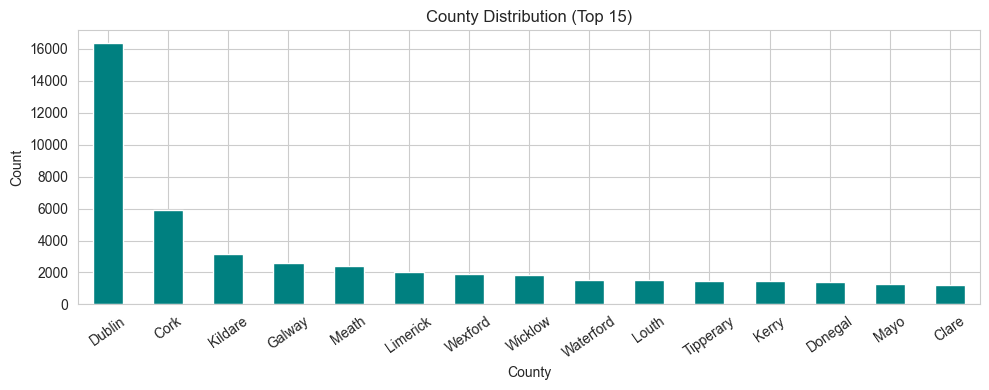

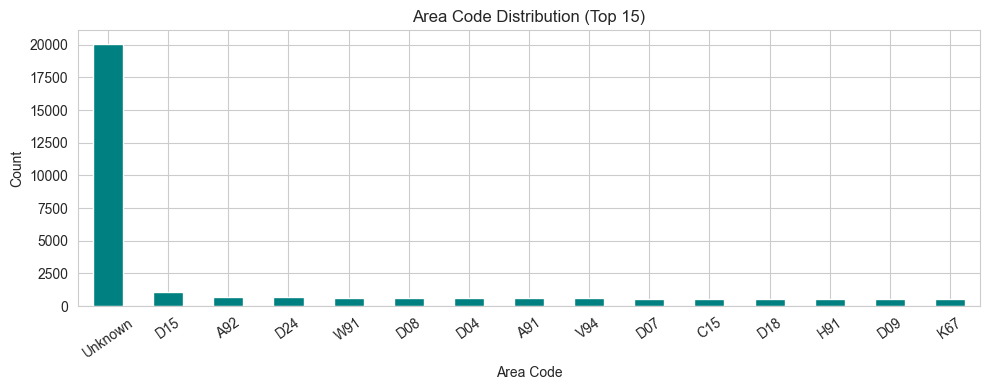

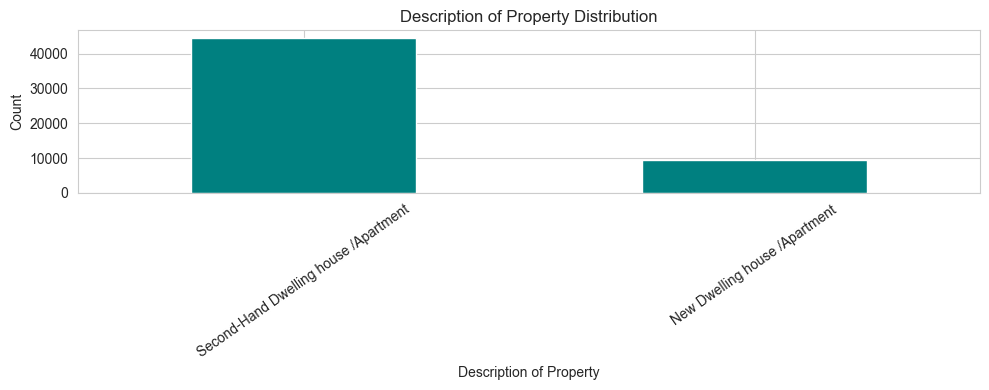

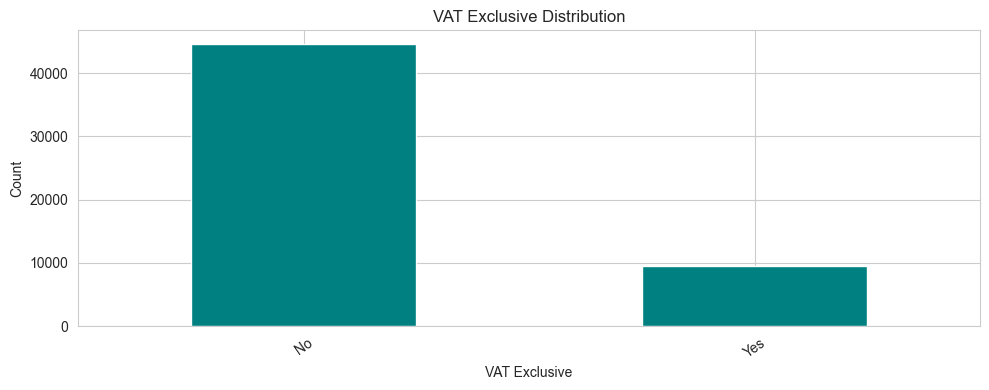

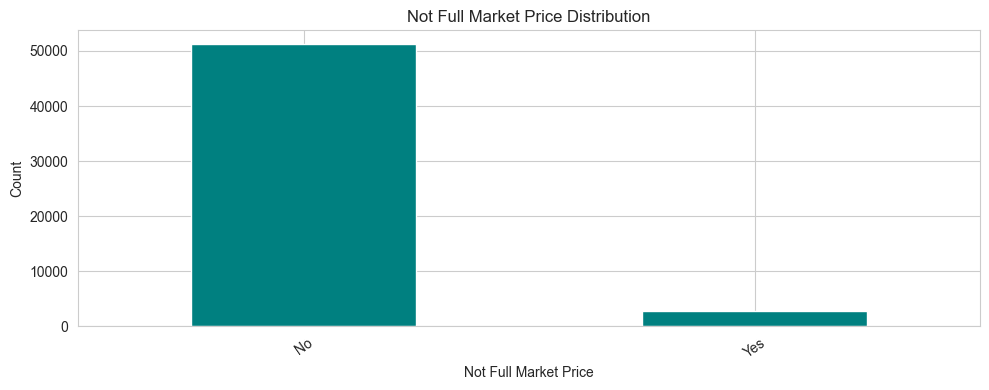

In [69]:
# Selected categorical feature plots

def plot_count_bar(df, col, title, top_n=None):
    vc = df[col].astype('string').fillna('<NA>').value_counts(dropna=False)
    if top_n is not None:
        vc = vc.head(top_n)

    plt.figure(figsize=(10, 4))
    vc.plot(kind='bar', color='teal')
    plt.title(title)
    plt.ylabel('Count')
    plt.xlabel(col)
    plt.xticks(rotation=35)
    plt.tight_layout()
    plt.show()

plot_count_bar(df_plot, 'County', 'County Distribution (Top 15)', top_n=15)
plot_count_bar(df_plot, 'Area Code', 'Area Code Distribution (Top 15)', top_n=15)
plot_count_bar(df_plot, 'Description of Property', 'Description of Property Distribution')
plot_count_bar(df_plot, 'VAT Exclusive', 'VAT Exclusive Distribution')
plot_count_bar(df_plot, 'Not Full Market Price', 'Not Full Market Price Distribution')


### VAT vs Property Type Consistency Check
This block quantifies the association between `VAT Exclusive` and `Is_Second_Hand`, then visualises both counts and row percentages.


New homes: 98.61% are VAT Exclusive = Yes (9455 / 9588)
Second-hand: 100.00% are VAT Exclusive = No (0 / 44404 yes)
Cramer's V (VAT vs Is_Second_Hand): 0.9916

Counts table (rows: Is_Second_Hand [No=New, Yes=Second-Hand], cols: VAT Exclusive):


VAT Exclusive,No,Yes
Is_Second_Hand,,
No,133,9455
Yes,44404,0



Row percentage table (%):


VAT Exclusive,No,Yes
Is_Second_Hand,,
No,1.39,98.61
Yes,100.00,0.00


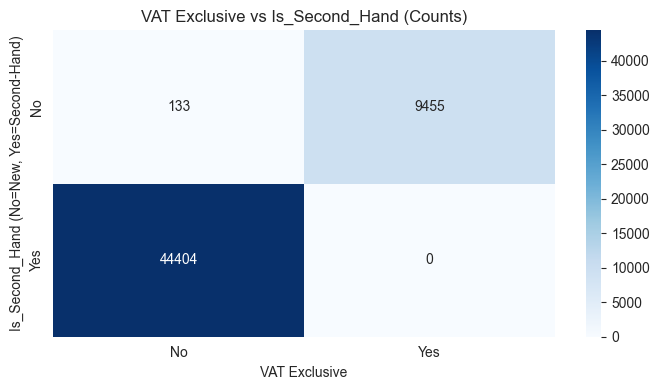

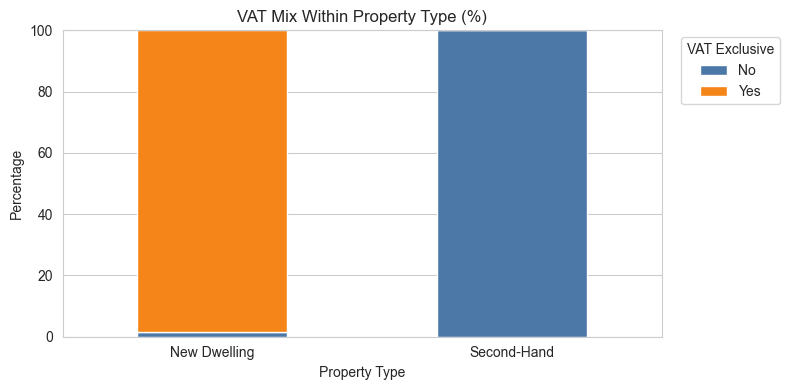

In [70]:
# VAT vs property-type consistency: summary + Cramer's V + visuals

vat_col = 'VAT Exclusive'
prop_col = 'Is_Second_Hand'

tmp = df_plot[[vat_col, prop_col]].copy()
tmp[vat_col] = tmp[vat_col].astype('string').str.strip()
tmp[prop_col] = tmp[prop_col].astype('string').str.strip()

# Is_Second_Hand convention in this notebook: No = New, Yes = Second-Hand
idx_order = ['No', 'Yes']
col_order = ['No', 'Yes']

ct_counts = pd.crosstab(tmp[prop_col], tmp[vat_col]).reindex(index=idx_order, columns=col_order, fill_value=0)
ct_pct = (pd.crosstab(tmp[prop_col], tmp[vat_col], normalize='index') * 100).reindex(index=idx_order, columns=col_order, fill_value=0)

new_total = int((tmp[prop_col] == 'No').sum())
new_vat_yes = int(((tmp[prop_col] == 'No') & (tmp[vat_col] == 'Yes')).sum())
new_vat_yes_pct = (new_vat_yes / new_total * 100) if new_total else np.nan

second_total = int((tmp[prop_col] == 'Yes').sum())
second_vat_yes = int(((tmp[prop_col] == 'Yes') & (tmp[vat_col] == 'Yes')).sum())
second_vat_no_pct = (1 - (second_vat_yes / second_total)) * 100 if second_total else np.nan

# Cramer's V
def cramers_v(a, b):
    tab = pd.crosstab(a, b)
    n = tab.to_numpy().sum()
    if n == 0:
        return np.nan
    obs = tab.to_numpy()
    row_sum = obs.sum(axis=1, keepdims=True)
    col_sum = obs.sum(axis=0, keepdims=True)
    exp = row_sum @ col_sum / n
    with np.errstate(divide='ignore', invalid='ignore'):
        chi2 = np.nansum((obs - exp) ** 2 / exp)
    r, k = obs.shape
    return np.sqrt((chi2 / n) / max(1, min(r - 1, k - 1)))

v = cramers_v(tmp[prop_col], tmp[vat_col])

print(f"New homes: {new_vat_yes_pct:.2f}% are VAT Exclusive = Yes ({new_vat_yes} / {new_total})")
print(f"Second-hand: {second_vat_no_pct:.2f}% are VAT Exclusive = No ({second_vat_yes} / {second_total} yes)")
print(f"Cramer's V (VAT vs Is_Second_Hand): {v:.4f}")

print('\nCounts table (rows: Is_Second_Hand [No=New, Yes=Second-Hand], cols: VAT Exclusive):')
display(ct_counts)

print('\nRow percentage table (%):')
display(ct_pct.round(2))

# Plot 1: Count heatmap
fig, ax = plt.subplots(figsize=(7, 4))
if USE_SEABORN:
    sns.heatmap(ct_counts, annot=True, fmt='d', cmap='Blues', ax=ax)
else:
    im = ax.imshow(ct_counts.values, cmap='Blues')
    for i in range(ct_counts.shape[0]):
        for j in range(ct_counts.shape[1]):
            ax.text(j, i, str(int(ct_counts.values[i, j])), ha='center', va='center', color='black')
    ax.set_xticks(range(ct_counts.shape[1]))
    ax.set_xticklabels(ct_counts.columns.tolist())
    ax.set_yticks(range(ct_counts.shape[0]))
    ax.set_yticklabels(ct_counts.index.tolist())
    fig.colorbar(im, ax=ax)

ax.set_title('VAT Exclusive vs Is_Second_Hand (Counts)')
ax.set_xlabel('VAT Exclusive')
ax.set_ylabel('Is_Second_Hand (No=New, Yes=Second-Hand)')
plt.tight_layout()
plt.show()

# Plot 2: Row percentage stacked bars
plot_pct = ct_pct.copy()
plot_pct.index = ['New Dwelling', 'Second-Hand']
fig, ax = plt.subplots(figsize=(8, 4))
plot_pct.plot(kind='bar', stacked=True, ax=ax, color=['#4c78a8', '#f58518'])
ax.set_title('VAT Mix Within Property Type (%)')
ax.set_xlabel('Property Type')
ax.set_ylabel('Percentage')
ax.legend(title='VAT Exclusive', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


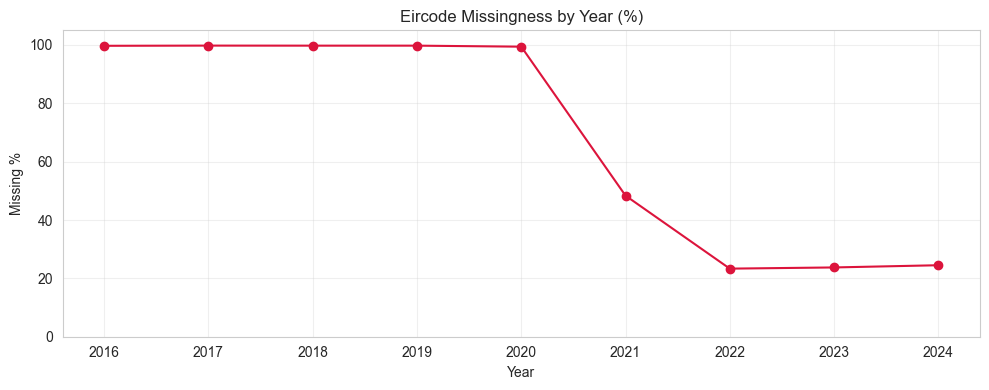

In [71]:
# Eircode missingness trend (important for DQR narrative)

eir_miss_year = (
    df_dqr_nodup
    .groupby(df_dqr_nodup[DATE_COL].dt.year)['Eircode']
    .apply(lambda s: s.isna().mean() * 100)
)

plt.figure(figsize=(10, 4))
plt.plot(eir_miss_year.index, eir_miss_year.values, marker='o', color='crimson')
plt.title('Eircode Missingness by Year (%)')
plt.xlabel('Year')
plt.ylabel('Missing %')
plt.ylim(0, 105)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [72]:
# Save a compact plot appendix for the report

with PdfPages('ppr-group-22312913-DQR-focused-plots.pdf') as pp:
    # 1) raw and log boxplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    if USE_SEABORN:
        sns.boxplot(x=df_plot[PRICE_COL], ax=axes[0], color='steelblue')
        sns.boxplot(x=np.log10(df_plot[PRICE_COL].clip(lower=1)), ax=axes[1], color='darkorange')
    else:
        axes[0].boxplot(df_plot[PRICE_COL].dropna(), vert=False)
        axes[1].boxplot(np.log10(df_plot[PRICE_COL].clip(lower=1)).dropna(), vert=False)
    axes[0].set_title('Price (€): Boxplot (Raw Scale)')
    axes[1].set_title('log10(Price): Boxplot')
    plt.tight_layout()
    pp.savefig(fig)
    plt.close(fig)

    # 2) monthly trend
    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.plot(monthly.index, monthly['median_price'], color='tab:blue')
    ax1.set_ylabel('Median price (€)', color='tab:blue')
    ax2 = ax1.twinx()
    ax2.bar(monthly.index, monthly['sales_count'], alpha=0.25, color='tab:gray', width=20)
    ax2.set_ylabel('Sales count', color='tab:gray')
    ax1.set_title('Monthly Median Price and Sales Count')
    fig.tight_layout()
    pp.savefig(fig)
    plt.close(fig)

    # 3) top counties
    fig = plt.figure(figsize=(13, 5))
    if USE_SEABORN:
        sns.boxplot(data=county_price, x='County', y=PRICE_COL, order=top_counties, showfliers=False)
    else:
        county_price.boxplot(column=PRICE_COL, by='County', showfliers=False, grid=False)
    plt.yscale('log')
    plt.title('Price by Top 10 Counties (Outliers Hidden, Log Scale)')
    plt.xlabel('County')
    plt.ylabel('Price (€), log scale')
    plt.xticks(rotation=35)
    plt.tight_layout()
    pp.savefig(fig)
    plt.close(fig)


    # 4) VAT vs Is_Second_Hand count heatmap
    fig, ax = plt.subplots(figsize=(7, 4))
    if USE_SEABORN:
        sns.heatmap(ct_counts, annot=True, fmt='d', cmap='Blues', ax=ax)
    else:
        im = ax.imshow(ct_counts.values, cmap='Blues')
        for i in range(ct_counts.shape[0]):
            for j in range(ct_counts.shape[1]):
                ax.text(j, i, str(int(ct_counts.values[i, j])), ha='center', va='center', color='black')
        ax.set_xticks(range(ct_counts.shape[1]))
        ax.set_xticklabels(ct_counts.columns.tolist())
        ax.set_yticks(range(ct_counts.shape[0]))
        ax.set_yticklabels(ct_counts.index.tolist())
        fig.colorbar(im, ax=ax)
    ax.set_title('VAT Exclusive vs Is_Second_Hand (Counts)')
    ax.set_xlabel('VAT Exclusive')
    ax.set_ylabel('Is_Second_Hand (No=New, Yes=Second-Hand)')
    plt.tight_layout()
    pp.savefig(fig)
    plt.close(fig)

    # 5) VAT mix within property type (%)
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_pct_pdf = ct_pct.copy()
    plot_pct_pdf.index = ['New Dwelling', 'Second-Hand']
    plot_pct_pdf.plot(kind='bar', stacked=True, ax=ax, color=['#4c78a8', '#f58518'])
    ax.set_title('VAT Mix Within Property Type (%)')
    ax.set_xlabel('Property Type')
    ax.set_ylabel('Percentage')
    ax.legend(title='VAT Exclusive', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    pp.savefig(fig)
    plt.close(fig)

print('Saved: ppr-group-22312913-DQR-focused-plots.pdf')


Saved: ppr-group-22312913-DQR-focused-plots.pdf


## Step 9: DQR Findings Summary (Notebook Version)

Suggested key findings to carry into your PDF report:
- Dataset has **54,000 rows, 9 features**, with **8 exact duplicate rows**.
- `Property Size Description` has very high missingness (~95%).
- `Eircode` has high missingness (~69%) and missingness is strongly time-dependent by year.
- `Price (€)` has extreme outliers (strong right skew), so robust summaries and boxplots are important.
- Routing-key strategy (`Eircode` first 3 chars) is a practical feature representation.
- Address+County inference materially reduces routing-key missingness while keeping error rate measurable and transparent.
- `VAT Exclusive` and `Is_Second_Hand` show near-deterministic association (Cramer's V close to 1), so they are likely redundant for baseline modeling.
- The canonical cleaned dataset for later project parts is `ppr-group-22312913-train-cleaned.csv` (9 features (including row_id), no NaN, reproducible dedup strategy).



## Part 2: Data Quality Plan (DQP)

Part 2 below is aligned to the **cleaned schema** used for downstream work: `ppr-group-22312913-train-cleaned.csv`.
The table captures final feature definitions, issues, options, and chosen actions for this 9-column dataset (including `row_id`).


In [73]:
dqp_plan = pd.DataFrame([
    {
        'Feature': 'row_id',
        'Final Type': 'Int64',
        'Issue(s)': 'Need stable traceability after cleaning and schema changes.',
        'Candidate Solutions': 'Use pandas index / explicit id column.',
        'Selected Action': 'Keep explicit row_id for deterministic linkage back to raw records.'
    },
    {
        'Feature': 'Year-Month of Sale (yyyy-mm)',
        'Final Type': 'string',
        'Issue(s)': 'Raw date had day-level granularity not required for baseline features.',
        'Candidate Solutions': 'Keep full date / keep year+month only.',
        'Selected Action': 'Use monthly representation in YYYY-MM format.'
    },
    {
        'Feature': 'Address_clean',
        'Final Type': 'string',
        'Issue(s)': 'High-cardinality text with formatting noise in raw addresses.',
        'Candidate Solutions': 'Drop / keep raw address / keep normalized address.',
        'Selected Action': 'Keep normalized address text with conservative suffix standardization (STREET->ST, ROAD->RD, AVENUE->AVE).'
    },
    {
        'Feature': 'County',
        'Final Type': 'category',
        'Issue(s)': 'Nominal categorical feature.',
        'Candidate Solutions': 'Object / category.',
        'Selected Action': 'Cast to category.'
    },
    {
        'Feature': 'Area Code',
        'Final Type': 'category',
        'Issue(s)': 'Derived from Eircode routing key with remaining missingness.',
        'Candidate Solutions': 'Drop / keep full Eircode / use area code + Unknown.',
        'Selected Action': 'Use 3-character area code; unresolved values set to Unknown.'
    },
    {
        'Feature': 'Price (€)',
        'Final Type': 'float64',
        'Issue(s)': 'Stored with currency formatting in raw file.',
        'Candidate Solutions': 'Keep text / parse numeric.',
        'Selected Action': 'Parse to numeric euro value.'
    },
    {
        'Feature': 'Not Full Market Price',
        'Final Type': 'category',
        'Issue(s)': 'Binary text feature.',
        'Candidate Solutions': 'Keep text / cast category / map to 0/1.',
        'Selected Action': 'Keep Yes/No labels and cast to category.'
    },
    {
        'Feature': 'VAT Exclusive',
        'Final Type': 'category',
        'Issue(s)': 'Binary text feature; strongly associated with property-type indicator.',
        'Candidate Solutions': 'Keep / drop due to redundancy.',
        'Selected Action': 'Keep for now; document near-redundancy with Is_Second_Hand.'
    },
    {
        'Feature': 'Is_Second_Hand',
        'Final Type': 'category',
        'Issue(s)': 'Derived indicator from property description labels.',
        'Candidate Solutions': 'Keep original labels only / derive binary indicator.',
        'Selected Action': 'Keep derived Yes/No indicator and cast to category.'
    },
])

display(dqp_plan)


,Feature,Final Type,Issue(s),Candidate Solutions,Selected Action
0,row_id,Int64,Need stable traceability after cleaning and sc...,Use pandas index / explicit id column.,Keep explicit row_id for deterministic linkage...
1,Year-Month of Sale (yyyy-mm),string,Raw date had day-level granularity not require...,Keep full date / keep year+month only.,Use monthly representation in YYYY-MM format.
2,Address_clean,string,High-cardinality text with formatting noise in...,Drop / keep raw address / keep normalized addr...,Keep normalized address text with conservative...
3,County,category,Nominal categorical feature.,Object / category.,Cast to category.
4,Area Code,category,Derived from Eircode routing key with remainin...,Drop / keep full Eircode / use area code + Unk...,Use 3-character area code; unresolved values s...
5,Price (€),float64,Stored with currency formatting in raw file.,Keep text / parse numeric.,Parse to numeric euro value.
6,Not Full Market Price,category,Binary text feature.,Keep text / cast category / map to 0/1.,Keep Yes/No labels and cast to category.
7,VAT Exclusive,category,Binary text feature; strongly associated with ...,Keep / drop due to redundancy.,Keep for now; document near-redundancy with Is...
8,Is_Second_Hand,category,Derived indicator from property description la...,Keep original labels only / derive binary indi...,Keep derived Yes/No indicator and cast to cate...


## Step 10: Finalise DQP Dataset (Cleaned Schema)


In [74]:
# Canonical dataset for downstream parts comes from the cleaned export created in Step 6.
df_final = df_part1_export.copy()

# Keep row_id as numeric traceability key
df_final['row_id'] = pd.to_numeric(df_final['row_id'], errors='coerce').astype('Int64')

# Standardize text columns
text_cols = [
    'Year-Month of Sale (yyyy-mm)',
    'Address_clean',
    'County',
    'Area Code',
    'Not Full Market Price',
    'VAT Exclusive',
    'Is_Second_Hand',
]
for col in text_cols:
    df_final[col] = df_final[col].astype('string').str.strip()

# Enforce numeric type for target
df_final['Price (€)'] = pd.to_numeric(df_final['Price (€)'], errors='coerce')

# Cast categorical columns
for col in ['County', 'Area Code', 'Not Full Market Price', 'VAT Exclusive', 'Is_Second_Hand']:
    df_final[col] = df_final[col].astype('category')

# Final no-NaN safety for cleaned schema
for col in df_final.columns:
    if str(df_final[col].dtype).startswith('category'):
        if df_final[col].isna().any():
            df_final[col] = df_final[col].cat.add_categories(['Unknown']).fillna('Unknown')
    elif pd.api.types.is_numeric_dtype(df_final[col]):
        if df_final[col].isna().any():
            df_final[col] = df_final[col].fillna(df_final[col].median())
    else:
        df_final[col] = df_final[col].fillna('Unknown')

# Format check for YYYY-MM
month_fmt_ok = df_final['Year-Month of Sale (yyyy-mm)'].str.match(r'^\d{4}-\d{2}$', na=False).all()
print('Year-Month format valid (YYYY-MM):', bool(month_fmt_ok))
print('DQP dataset aligned to cleaned schema.')


Year-Month format valid (YYYY-MM): True
DQP dataset aligned to cleaned schema.


## Step 11: Validation of Canonical Cleaned Dataset


In [75]:
print('Final shape:', df_final.shape)
print('Final duplicate rows (full row, includes row_id):', int(df_final.duplicated().sum()))

if 'dup_key_count_before_export' in globals():
    print('Duplicates on strict full-date dup_key before month aggregation:', dup_key_count_before_export)

non_id_cols = [c for c in df_final.columns if c != 'row_id']
dup_non_id = int(df_final.duplicated(subset=non_id_cols).sum())
print('Potential duplicates excluding row_id:', dup_non_id)
if dup_non_id > 0:
    print('Note: these can occur when different sale days collapse to the same YYYY-MM value; rows are retained intentionally for reproducibility.')

missing_final = df_final.isna().sum().sort_values(ascending=False)
print('\nMissing values by column:')
print(missing_final)
print('Total missing values:', int(missing_final.sum()))

print('\nFinal dtypes:')
print(df_final.dtypes)

unknown_area_pct = (df_final['Area Code'].astype('string') == 'Unknown').mean() * 100
print(f'Unknown Area Code %: {unknown_area_pct:.2f}%')

display(df_final.head(5))


Final shape: (53992, 9)
Final duplicate rows (full row, includes row_id): 0
Duplicates on strict full-date dup_key before month aggregation: 0
Potential duplicates excluding row_id: 1
Note: these can occur when different sale days collapse to the same YYYY-MM value; rows are retained intentionally for reproducibility.

Missing values by column:
row_id                          0
Year-Month of Sale (yyyy-mm)    0
Address_clean                   0
County                          0
Area Code                       0
Price (€)                       0
Not Full Market Price           0
VAT Exclusive                   0
Is_Second_Hand                  0
dtype: int64
Total missing values: 0

Final dtypes:
row_id                             Int64
Year-Month of Sale (yyyy-mm)      string
Address_clean                     string
County                          category
Area Code                       category
Price (€)                        Float64
Not Full Market Price           category
VAT Excl

,row_id,Year-Month of Sale (yyyy-mm),Address_clean,County,Area Code,Price (€),Not Full Market Price,VAT Exclusive,Is_Second_Hand
0,1,2016-04,7 MARLTON DEMESNE DEMESNE WICKLOW,Wicklow,Unknown,"450,000.00",No,No,Yes
1,2,2016-09,90 SLIEVE RUA DR KILMACUD BLACKROCK,Dublin,A94,"560,000.00",No,No,Yes
2,3,2016-12,APT 1 ABOVE BERGERACS MAIN ST ROASREA,Tipperary,Unknown,"44,200.00",No,No,Yes
3,4,2016-08,6 MARIEMOUNT GROVE BALLINAMORE COUNTY LEITRIM,Leitrim,Unknown,"65,000.00",No,No,Yes
4,5,2016-04,THE GLADE TYMULLEN MONASTERBOICE,Louth,Unknown,"400,000.00",No,No,Yes


## Step 12: Export Canonical Cleaned Dataset


In [76]:
canonical_path = 'ppr-group-22312913-train-cleaned.csv'

# Canonical export used for Parts 3-5
df_final.to_csv(canonical_path, index=False)

# Optional DQP plan table for appendix
dqp_plan.to_csv('ppr-group-22312913-dqp-plan-table.csv', index=False)

print('Saved canonical cleaned dataset:', canonical_path)
print('Saved: ppr-group-22312913-dqp-plan-table.csv')


Saved canonical cleaned dataset: ppr-group-22312913-train-cleaned.csv
Saved: ppr-group-22312913-dqp-plan-table.csv


## Part 5- Training and Evaluating prediction models ##

This section uses the canonical cleaned training dataset produced earlier to build predictive models for property price. The aim is to predict property price using the descriptive features selected in Part 4, compare model performance using multiple evaluation methods, and discuss model interpretation and possible improvements.

In [77]:
import pandas as pd
import numpy as np

df_model= pd.read_csv("ppr-group-22312913-train-cleaned.csv")
df_model.head()


,row_id,Year-Month of Sale (yyyy-mm),Address_clean,County,Area Code,Price (€),Not Full Market Price,VAT Exclusive,Is_Second_Hand
0,1,2016-04,7 MARLTON DEMESNE DEMESNE WICKLOW,Wicklow,Unknown,"450,000.00",No,No,Yes
1,2,2016-09,90 SLIEVE RUA DR KILMACUD BLACKROCK,Dublin,A94,"560,000.00",No,No,Yes
2,3,2016-12,APT 1 ABOVE BERGERACS MAIN ST ROASREA,Tipperary,Unknown,"44,200.00",No,No,Yes
3,4,2016-08,6 MARIEMOUNT GROVE BALLINAMORE COUNTY LEITRIM,Leitrim,Unknown,"65,000.00",No,No,Yes
4,5,2016-04,THE GLADE TYMULLEN MONASTERBOICE,Louth,Unknown,"400,000.00",No,No,Yes


### 5.1 Preparing the target variable

The target variable `Price (€)` is strongly right-skewed, with a small number of very expensive properties creating a long upper tail. To reduce skewness and stabilise variance, a logarithmic transformation was applied using `log1p`. The transformed variable `log_price` is used as the prediction target in the models below.

In [78]:
df_model["log_price"] = np.log1p(df_model["Price (€)"])
df_model[["Price (€)", "log_price"]].head()

,Price (€),log_price
0,"450,000.00",13.02
1,"560,000.00",13.24
2,"44,200.00",10.70
3,"65,000.00",11.08
4,"400,000.00",12.90


### 5.2 Selecting descriptive features

The selected descriptive features were taken from the cleaned dataset and reflect factors expected to influence property prices. These include location (`County`, `Area Code`), transaction characteristics (`Not Full Market Price`, `VAT Exclusive`), property type (`Is_Second_Hand`), and time of sale (`Year-Month of Sale (yyyy-mm)`).

In [79]:
feature_cols = [
    "County",
    "Area Code",
    "Not Full Market Price",
    "VAT Exclusive",
    "Is_Second_Hand",
    "Year-Month of Sale (yyyy-mm)"
]

X = df_model[feature_cols].copy()
y = df_model["log_price"].copy()

X.head()

,County,Area Code,Not Full Market Price,VAT Exclusive,Is_Second_Hand,Year-Month of Sale (yyyy-mm)
0,Wicklow,Unknown,No,No,Yes,2016-04
1,Dublin,A94,No,No,Yes,2016-09
2,Tipperary,Unknown,No,No,Yes,2016-12
3,Leitrim,Unknown,No,No,Yes,2016-08
4,Louth,Unknown,No,No,Yes,2016-04


### 5.3 Encoding categorical predictors

Several of the selected predictors are categorical, so one-hot encoding was applied to convert them into numerical features suitable for machine learning models. The option `drop_first=True` was used so that one category is treated as the reference level, which helps avoid perfect multicollinearity in linear models.

In [80]:
X_encoded = pd.get_dummies(X, drop_first=True)
print(X_encoded.shape)
X_encoded.head()

(53992, 288)


,County_Cavan,County_Clare,County_Cork,County_Donegal,County_Dublin,County_Galway,County_Kerry,County_Kildare,County_Kilkenny,County_Laois,County_Leitrim,County_Limerick,County_Longford,County_Louth,County_Mayo,County_Meath,County_Monaghan,County_Offaly,County_Roscommon,County_Sligo,County_Tipperary,County_Waterford,County_Westmeath,County_Wexford,County_Wicklow,Area Code_A42,Area Code_A45,Area Code_A63,Area Code_A65,Area Code_A67,Area Code_A75,Area Code_A81,Area Code_A82,Area Code_A83,Area Code_A84,Area Code_A85,Area Code_A86,Area Code_A91,Area Code_A92,Area Code_A94,Area Code_A96,Area Code_A98,Area Code_C15,Area Code_C95,Area Code_D01,Area Code_D02,Area Code_D03,Area Code_D04,Area Code_D05,Area Code_D06,Area Code_D07,Area Code_D08,Area Code_D09,Area Code_D10,Area Code_D11,Area Code_D12,Area Code_D13,Area Code_D14,Area Code_D15,Area Code_D16,Area Code_D17,Area Code_D18,Area Code_D20,Area Code_D22,Area Code_D24,Area Code_D6W,Area Code_E21,Area Code_E24,Area Code_E25,Area Code_E28,Area Code_E32,Area Code_E34,Area Code_E41,Area Code_E45,Area Code_E53,Area Code_E91,Area Code_F12,Area Code_F23,Area Code_F26,Area Code_F28,Area Code_F31,Area Code_F35,Area Code_F42,Area Code_F45,Area Code_F52,Area Code_F56,Area Code_F91,Area Code_F92,Area Code_F93,Area Code_F94,Area Code_H12,Area Code_H14,Area Code_H16,Area Code_H18,Area Code_H23,Area Code_H53,Area Code_H54,Area Code_H62,Area Code_H65,Area Code_H71,Area Code_H91,Area Code_K32,Area Code_K34,Area Code_K36,Area Code_K45,Area Code_K56,Area Code_K67,Area Code_K78,Area Code_N37,Area Code_N39,Area Code_N41,Area Code_N42,Area Code_N91,Area Code_P12,Area Code_P14,Area Code_P17,Area Code_P23,Area Code_P24,Area Code_P25,Area Code_P31,Area Code_P32,Area Code_P36,Area Code_P43,Area Code_P47,Area Code_P51,Area Code_P52,Area Code_P56,Area Code_P61,Area Code_P62,Area Code_P67,Area Code_P72,Area Code_P75,Area Code_P81,Area Code_P85,Area Code_R14,Area Code_R21,Area Code_R32,Area Code_R35,Area Code_R42,Area Code_R45,Area Code_R51,Area Code_R56,Area Code_R93,Area Code_R95,Area Code_R96,Area Code_T12,Area Code_T23,Area Code_T34,Area Code_T45,Area Code_T56,Area Code_Unknown,Area Code_V14,Area Code_V15,Area Code_V23,Area Code_V31,Area Code_V34,Area Code_V35,Area Code_V42,Area Code_V92,Area Code_V93,Area Code_V94,Area Code_V95,Area Code_W12,Area Code_W19,Area Code_W23,Area Code_W34,Area Code_W53,Area Code_W91,Area Code_X34,Area Code_X35,Area Code_X42,Area Code_X91,Area Code_Y14,Area Code_Y21,Area Code_Y25,Area Code_Y34,Area Code_Y35,Area Code_Y43,Not Full Market Price_Yes,VAT Exclusive_Yes,Is_Second_Hand_Yes,Year-Month of Sale (yyyy-mm)_2016-02,Year-Month of Sale (yyyy-mm)_2016-03,Year-Month of Sale (yyyy-mm)_2016-04,Year-Month of Sale (yyyy-mm)_2016-05,Year-Month of Sale (yyyy-mm)_2016-06,Year-Month of Sale (yyyy-mm)_2016-07,Year-Month of Sale (yyyy-mm)_2016-08,Year-Month of Sale (yyyy-mm)_2016-09,Year-Month of Sale (yyyy-mm)_2016-10,Year-Month of Sale (yyyy-mm)_2016-11,Year-Month of Sale (yyyy-mm)_2016-12,Year-Month of Sale (yyyy-mm)_2017-01,Year-Month of Sale (yyyy-mm)_2017-02,Year-Month of Sale (yyyy-mm)_2017-03,Year-Month of Sale (yyyy-mm)_2017-04,Year-Month of Sale (yyyy-mm)_2017-05,Year-Month of Sale (yyyy-mm)_2017-06,Year-Month of Sale (yyyy-mm)_2017-07,Year-Month of Sale (yyyy-mm)_2017-08,Year-Month of Sale (yyyy-mm)_2017-09,Year-Month of Sale (yyyy-mm)_2017-10,Year-Month of Sale (yyyy-mm)_2017-11,Year-Month of Sale (yyyy-mm)_2017-12,Year-Month of Sale (yyyy-mm)_2018-01,Year-Month of Sale (yyyy-mm)_2018-02,Year-Month of Sale (yyyy-mm)_2018-03,Year-Month of Sale (yyyy-mm)_2018-04,Year-Month of Sale (yyyy-mm)_2018-05,Year-Month of Sale (yyyy-mm)_2018-06,Year-Month of Sale (yyyy-mm)_2018-07,Year-Month of Sale (yyyy-mm)_2018-08,Year-Month of Sale (yyyy-mm)_2018-09,Year-Month of Sale (yyyy-mm)_2018-10,Year-Month of Sale (yyyy-mm)_2018-11,Year-Month of Sale (yyyy-mm)_2018-12,Year-Month of Sale (yyyy-mm)_2019-01,Year-Month of Sale (yyyy-mm)_2019-02,Year-Month of Sale (yyyy-mm)_2019-03,Year-Month of Sale (

### 5.4 Train–validation split

To evaluate model performance on unseen data, the encoded dataset was split into training and validation subsets using an 80/20 split.  
The training data is used to fit the models, while the validation set provides an estimate of model performance on data that was not used during training.

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(43193, 288)
(10799, 288)
(43193,)
(10799,)


### 5.5 Baseline model: Linear Regression

Linear Regression was used as a baseline model because it is simple, interpretable, and provides a useful reference point for comparing more flexible models.

In [82]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_val_pred = lr.predict(X_val)
lr_train_pred = lr.predict(X_train)

In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_val_mae = mean_absolute_error(y_val, lr_val_pred)
lr_val_rmse = np.sqrt(mean_squared_error(y_val, lr_val_pred))
lr_val_r2 = r2_score(y_val, lr_val_pred)

lr_train_r2 = r2_score(y_train, lr_train_pred)

print("Linear Regression Validation MAE:", lr_val_mae)
print("Linear Regression Validation RMSE:", lr_val_rmse)
print("Linear Regression Validation R2:", lr_val_r2)
print("Linear Regression Training R2:", lr_train_r2)

Linear Regression Validation MAE: 0.41722333181412163
Linear Regression Validation RMSE: 0.591516249830955
Linear Regression Validation R2: 0.4218795519706171
Linear Regression Training R2: 0.4411931206972073


### 5.6 Random Forest model

Random Forest was evaluated as a more flexible nonlinear model that can capture more complex patterns and interactions between predictors.

In [84]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_val_pred = rf.predict(X_val)
rf_train_pred = rf.predict(X_train)

In [85]:
rf_val_mae = mean_absolute_error(y_val, rf_val_pred)
rf_val_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_val_r2 = r2_score(y_val, rf_val_pred)

rf_train_r2 = r2_score(y_train, rf_train_pred)

print("Random Forest Validation MAE:", rf_val_mae)
print("Random Forest Validation RMSE:", rf_val_rmse)
print("Random Forest Validation R2:", rf_val_r2)
print("Random Forest Training R2:", rf_train_r2)

Random Forest Validation MAE: 0.4508331801981392
Random Forest Validation RMSE: 0.6328685738125853
Random Forest Validation R2: 0.3382224471732381
Random Forest Training R2: 0.6619592705549007


### 5.7 Cross-validation

To obtain a more robust estimate of model performance, five-fold cross-validation was applied to the cleaned training dataset. Cross-validation repeatedly splits the data into training and validation folds, allowing model performance to be averaged across multiple data partitions.

In [86]:
from sklearn.model_selection import cross_val_score

# Linear Regression cross-validation
lr_cv_r2 = cross_val_score(
    lr,
    X_encoded,
    y,
    cv=5,
    scoring="r2"
)

print("Linear Regression CV R2 mean:", lr_cv_r2.mean())

# Random Forest cross-validation
rf_cv_r2 = cross_val_score(
    rf,
    X_encoded,
    y,
    cv=5,
    scoring="r2"
)

print("Random Forest CV R2 mean:", rf_cv_r2.mean())

Linear Regression CV R2 mean: 0.2408760510586571
Random Forest CV R2 mean: 0.19715237352668294


### 5.8 Model comparison

The cross-validation results show that Linear Regression slightly outperforms Random Forest in terms of R². This suggests that the relationships between the available predictors and property prices are largely additive and can be captured effectively by a linear model.

Although Random Forest is capable of modelling more complex nonlinear patterns, the current feature set may not contain strong nonlinear relationships that benefit from this flexibility. As a result, the simpler Linear Regression model generalises slightly better in cross-validation.

### 5.9 Preparing the hold-out test dataset

Before evaluating the models on the hold-out test dataset, the same feature creation steps used for the cleaned training data were applied to the test set. This ensures that the training and test datasets contain the same descriptive variables and are represented consistently.

In [88]:
df_test = pd.read_csv("ppr-group-22312913-test.csv")
df_test.head()

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
0,18/02/2025,"12 ST GABRIELS PLACE, NAAS, KILDARE",Kildare,W91X3HP,"€315,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
1,11/12/2025,"KYLEEN EAST, ELPHIN, ROSCOMMOV",Roscommon,NaN,"€200,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
2,23/09/2025,"9 SUPPLE PARK SHOPPING CENTRE, DUNSHAUGHLIN, C...",Meath,A85AK06,"€180,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN
3,29/05/2025,"1 HAYMARKET, DROGHEDA, LOUTH",Louth,A92X627,"€272,500.00",No,No,Second-Hand Dwelling house /Apartment,NaN
4,25/09/2025,"32 OAKLEY RD, RANELAGH, DUBLIN 6",Dublin,D06N923,"€2,250,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN


In [89]:
# Create Year-Month of Sale (yyyy-mm)
df_test["Year-Month of Sale (yyyy-mm)"] = pd.to_datetime(
    df_test["Date of Sale (dd/mm/yyyy)"],
    dayfirst=True,
    errors="coerce"
).dt.strftime("%Y-%m")

# Create Area Code from Eircode
df_test["Area Code"] = df_test["Eircode"].fillna("Unknown").astype(str).str[:3]

# Create Is_Second_Hand from Description of Property
df_test["Is_Second_Hand"] = np.where(
    df_test["Description of Property"].str.contains("Second-Hand", case=False, na=False),
    "Yes",
    "No"
)

In [90]:
print(df_test[[
    "County",
    "Area Code",
    "Not Full Market Price",
    "VAT Exclusive",
    "Is_Second_Hand",
    "Year-Month of Sale (yyyy-mm)"
]].head())

      County Area Code Not Full Market Price VAT Exclusive Is_Second_Hand  \
0    Kildare       W91                    No            No            Yes   
1  Roscommon       Unk                    No            No            Yes   
2      Meath       A85                    No            No            Yes   
3      Louth       A92                    No            No            Yes   
4     Dublin       D06                    No            No            Yes   

  Year-Month of Sale (yyyy-mm)  
0                      2025-02  
1                      2025-12  
2                      2025-09  
3                      2025-05  
4                      2025-09  


In [92]:
df_test["Price (€)"] = (
    df_test["Price (€)"]
    .astype(str)
    .str.replace("€", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df_test["Price (€)"] = pd.to_numeric(df_test["Price (€)"], errors="coerce")

print(df_test["Price (€)"].dtype)
print(df_test["Price (€)"].head())

float64
0     315,000.00
1     200,000.00
2     180,000.00
3     272,500.00
4   2,250,000.00
Name: Price (€), dtype: float64


In [93]:
X_test = df_test[feature_cols].copy()

X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_encoded.columns, fill_value=0)
y_test = np.log1p(df_test["Price (€)"])


In [95]:
df_test.to_csv("ppr-group-22312913-test-cleaned.csv", index=False)
print("Saved cleaned test set: ppr-group-22312913-test-cleaned.csv")

Saved cleaned test set: ppr-group-22312913-test-cleaned.csv


### 5.9 Evaluation on the hold-out test dataset

To assess how well the models generalise to completely unseen data, predictions were also evaluated on the hold-out test dataset provided with the project. The same feature preparation steps used for the training data were applied to the test set to ensure consistency.

In [96]:
lr_test_pred = lr.predict(X_test_encoded)
rf_test_pred = rf.predict(X_test_encoded)

In [97]:
lr_test_mae = mean_absolute_error(y_test, lr_test_pred)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_test_pred))
lr_test_r2 = r2_score(y_test, lr_test_pred)

rf_test_mae = mean_absolute_error(y_test, rf_test_pred)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("Linear Regression Test R2:", lr_test_r2)
print("Random Forest Test R2:", rf_test_r2)

Linear Regression Test R2: -0.3200099697502108
Random Forest Test R2: -0.059144031713979084


### 5.9 Evaluation on the hold-out test dataset

To assess how well the models generalise to completely unseen data, predictions were evaluated on the hold-out test dataset provided with the project. The same feature preparation steps used for the training data were applied to the test set to ensure consistency between the training and testing feature matrices.

In [99]:
lr_test_pred = lr.predict(X_test_encoded)
rf_test_pred = rf.predict(X_test_encoded)

In [100]:
lr_test_mae = mean_absolute_error(y_test, lr_test_pred)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_test_pred))
lr_test_r2 = r2_score(y_test, lr_test_pred)

rf_test_mae = mean_absolute_error(y_test, rf_test_pred)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("Linear Regression Test MAE:", lr_test_mae)
print("Linear Regression Test RMSE:", lr_test_rmse)
print("Linear Regression Test R2:", lr_test_r2)

print("Random Forest Test MAE:", rf_test_mae)
print("Random Forest Test RMSE:", rf_test_rmse)
print("Random Forest Test R2:", rf_test_r2)

Linear Regression Test MAE: 0.6241962315860835
Linear Regression Test RMSE: 0.7659786154201286
Linear Regression Test R2: -0.3200099697502108
Random Forest Test MAE: 0.5210265707878323
Random Forest Test RMSE: 0.6861286453211365
Random Forest Test R2: -0.059144031713979084


### 5.10 Evaluation on the hold-out test dataset

The results on the hold-out test dataset show that the Random Forest model performs better than Linear Regression, achieving lower MAE and RMSE values.

Both models produce relatively low predictive performance, with negative R² values on the test dataset. A negative R² indicates that the model performs worse than predicting the average value of the target variable.

This outcome is likely due to the limited set of explanatory features available in the dataset. Important determinants of property prices, such as property size, number of bedrooms, location within cities, and proximity to amenities, are not included in the dataset. As a result, the models have limited information with which to explain the variation in property prices.

### 5.11 Model improvement: Ridge Regression

To explore whether regularisation can improve predictive performance, Ridge Regression was evaluated as an extension of Linear Regression. Ridge Regression applies an L2 penalty to the regression coefficients, which can reduce overfitting and improve generalisation when many predictors are present.

In [101]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_val_pred = ridge.predict(X_val)
ridge_train_pred = ridge.predict(X_train)

In [102]:
ridge_val_mae = mean_absolute_error(y_val, ridge_val_pred)
ridge_val_rmse = np.sqrt(mean_squared_error(y_val, ridge_val_pred))
ridge_val_r2 = r2_score(y_val, ridge_val_pred)

ridge_train_r2 = r2_score(y_train, ridge_train_pred)

print("Ridge Validation MAE:", ridge_val_mae)
print("Ridge Validation RMSE:", ridge_val_rmse)
print("Ridge Validation R2:", ridge_val_r2)
print("Ridge Training R2:", ridge_train_r2)

Ridge Validation MAE: 0.41722450127449556
Ridge Validation RMSE: 0.5915127265888622
Ridge Validation R2: 0.4218864388557422
Ridge Training R2: 0.441061622588258


### Ridge Regression results

Ridge Regression achieved better validation performance compared to the baseline Linear Regression model. The regularisation term helps stabilise the coefficient estimates when many encoded categorical variables are present.

The training and validation R² values are relatively close (0.441 vs 0.422), suggesting that the model generalises reasonably well and does not exhibit strong overfitting.

These results indicate that regularised linear models can improve predictive performance when dealing with datasets containing many categorical predictors.

### 5.12 Model interpretation

One advantage of linear models is that they are interpretable. The regression coefficients indicate how each predictor influences the predicted log property price while holding other variables constant.

In [103]:
coef_table = pd.Series(lr.coef_, index=X_encoded.columns)
coef_table.sort_values(ascending=False).head(10)

County_Dublin                          0.86
Area Code_E28                          0.69
Area Code_X34                          0.60
Year-Month of Sale (yyyy-mm)_2024-10   0.60
Year-Month of Sale (yyyy-mm)_2024-08   0.59
Year-Month of Sale (yyyy-mm)_2024-06   0.56
County_Kildare                         0.56
Year-Month of Sale (yyyy-mm)_2024-11   0.55
Year-Month of Sale (yyyy-mm)_2024-09   0.54
County_Wicklow                         0.53
dtype: float64

In [104]:
coef_table.sort_values().head(10)

Area Code_P23   -1.32
Area Code_P56   -0.88
Area Code_H53   -0.85
Area Code_R14   -0.80
Area Code_V15   -0.80
Area Code_D10   -0.79
Area Code_H23   -0.77
Area Code_K32   -0.75
Area Code_D17   -0.71
Area Code_P67   -0.68
dtype: float64

The coefficients provide insight into how different predictors influence property prices. Positive coefficients indicate that the presence of a particular feature increases the predicted log price, while negative coefficients indicate a decrease.

For example, certain counties may show positive effects reflecting higher average property prices in those regions. Similarly, indicators related to transaction conditions or property type may influence predicted prices depending on market characteristics.